# Dataset Quality Review

Visualize kept and dropped images with drop reasons and key metrics.


In [1]:
import sys
from pathlib import Path
import math
import textwrap

import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / "dataset_quality").exists():
    root = root.parent
sys.path.insert(0, str(root))

REPORT_DIR = root / "datasets/appa-real-dataset_v2_improved/reports"
QUALITY_CSV = REPORT_DIR / "quality_report.csv"
FIGURES_DIR = root / "figures"
SAVE_FIGURES = True
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(QUALITY_CSV)
if "drop_reasons_str" not in df.columns:
    df["drop_reasons_str"] = df.get("drop_reasons", "").astype(str)
df["drop_reasons_str"] = df["drop_reasons_str"].fillna("")

kept_df = df[df["keep"]].copy()
dropped_df = df[~df["keep"]].copy()

DEFAULT_FIELDS = [
    c
    for c in ["roi_tenengrad", "roi_lap_var", "jpeg_blockiness", "niqe", "brisque", "black_bar_score"]
    if c in df.columns
]

METRIC_FILENAME_MAP = {
    "jpeg_blockiness": "jpg_blockiness.png",
    "black_bar_score": "bar_score.png",
}

def _save_figure(fig, filename):
    if not SAVE_FIGURES:
        return
    fig_path = FIGURES_DIR / filename
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure -> {fig_path}")


In [2]:
def _format_label(row, fields):
    parts = []
    if row.get("drop_reasons_str"):
        parts.append(row["drop_reasons_str"])
    for field in fields:
        val = row.get(field)
        if pd.notna(val):
            parts.append(f"{field}={val:.2f}")
    return " | ".join(parts)


def _make_grid(subset, fields, cols=4, thumb=200):
    rows = int(math.ceil(len(subset) / float(cols)))
    grid = Image.new("RGB", (cols * thumb, rows * thumb), color=(12, 12, 12))
    draw = ImageDraw.Draw(grid)
    font = ImageFont.load_default()

    for idx, row in enumerate(subset.itertuples(index=False)):
        path = Path(row.image_path)
        if not path.exists():
            continue
        img = Image.open(path).convert("RGB")
        img = img.resize((thumb, thumb), Image.LANCZOS)
        x = (idx % cols) * thumb
        y = (idx // cols) * thumb
        grid.paste(img, (x, y))

        label = _format_label(row._asdict(), fields)
        if label:
            lines = textwrap.wrap(label, width=28)
            line_h = 12
            block_h = min(thumb, len(lines) * line_h + 4)
            draw.rectangle([x, y, x + thumb, y + block_h], fill=(0, 0, 0))
            for i, line in enumerate(lines):
                draw.text((x + 2, y + 2 + i * line_h), line, fill=(255, 255, 255), font=font)
    return grid


def show_grid(df_in, title, fields=None, n=16, seed=0, sort_by=None, ascending=True):
    fields = fields or DEFAULT_FIELDS
    if sort_by and sort_by in df_in.columns:
        subset = df_in.dropna(subset=[sort_by]).sort_values(sort_by, ascending=ascending).head(n)
    else:
        subset = df_in.sample(n=min(n, len(df_in)), random_state=seed)
    grid = _make_grid(subset, fields=fields, cols=int(math.sqrt(n)) or 1)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()


## Random samples

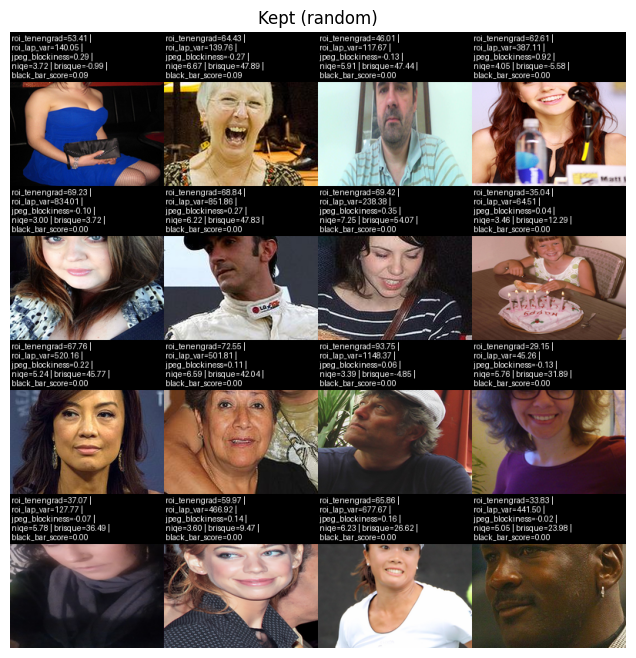

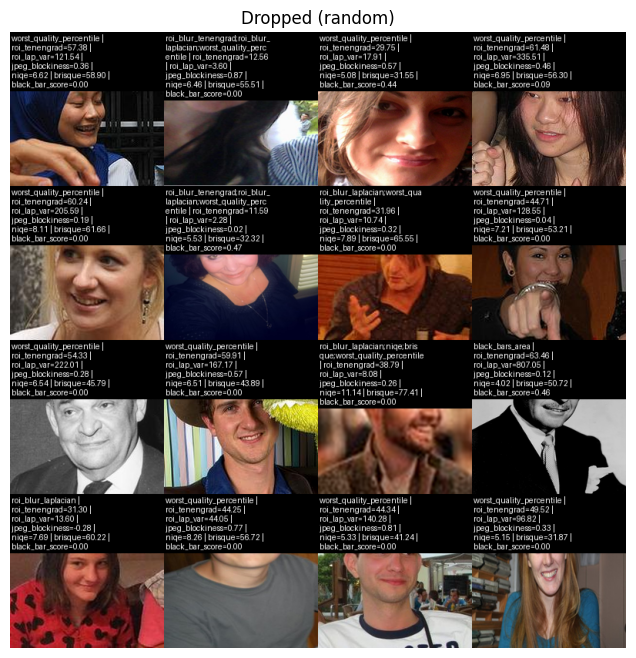

In [3]:
show_grid(kept_df, "Kept (random)", n=16, seed=1)
show_grid(dropped_df, "Dropped (random)", n=16, seed=1)

## Worst cases by metric

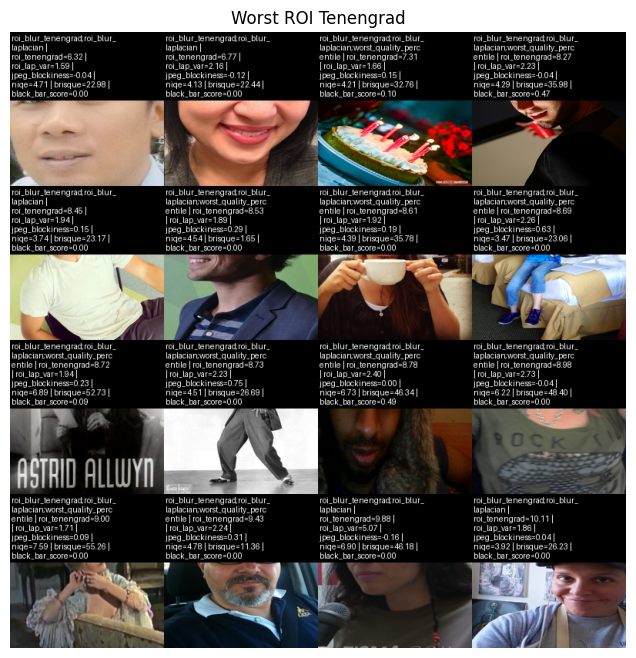

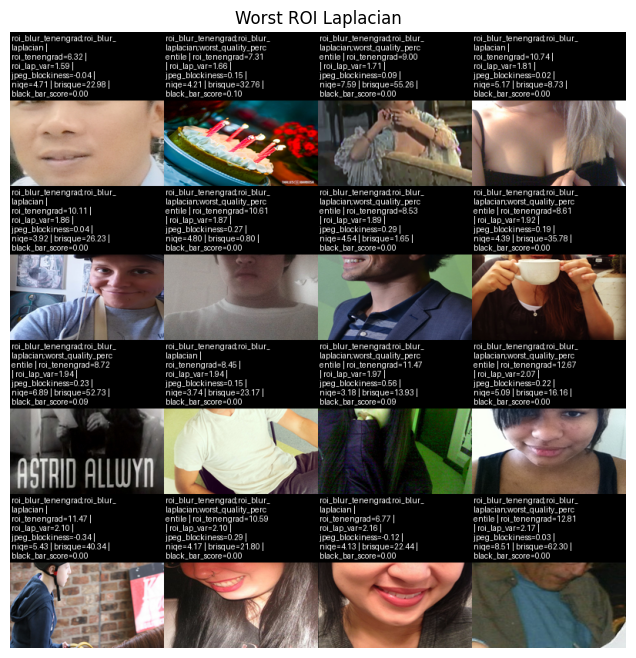

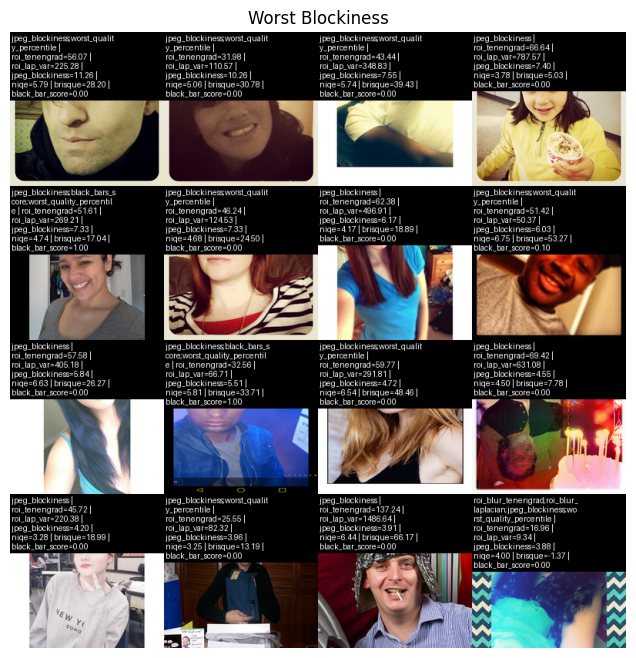

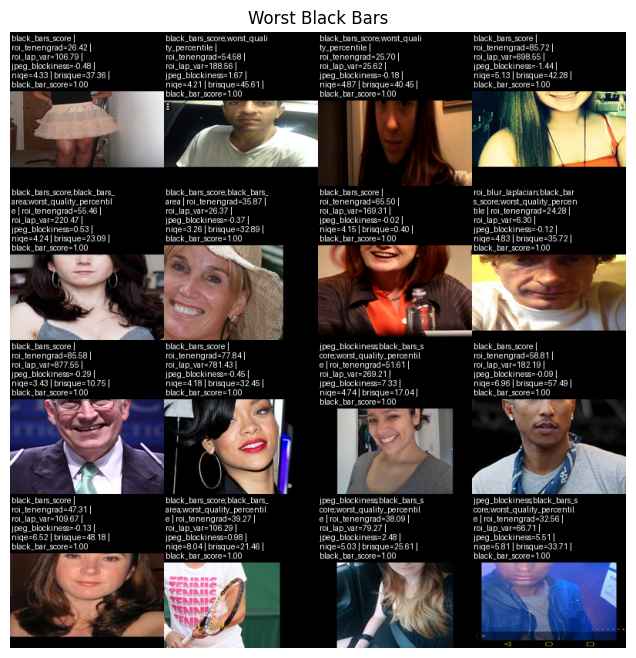

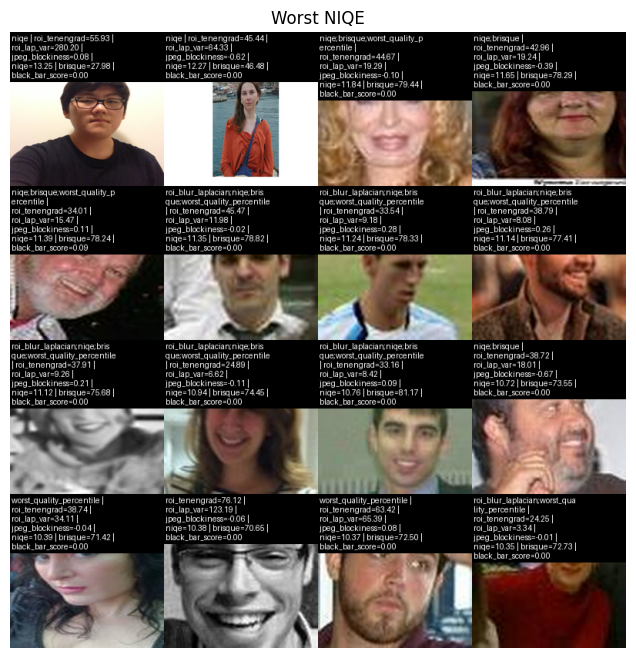

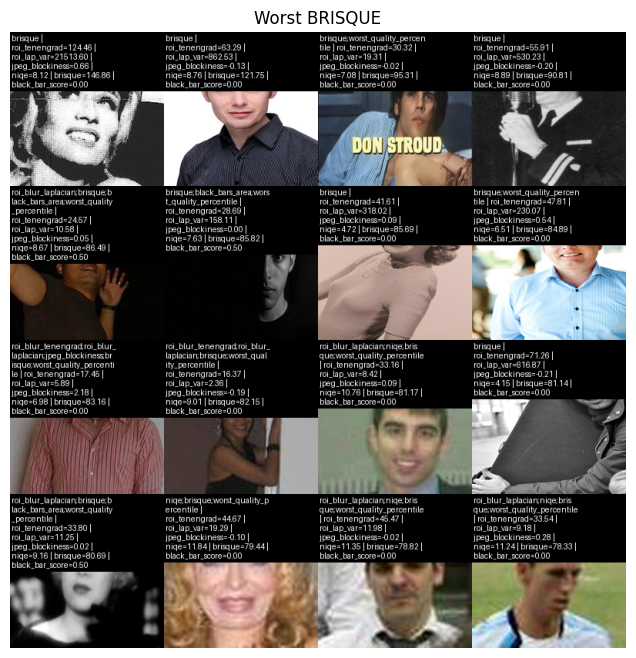

In [4]:
if "roi_tenengrad" in df.columns:
    show_grid(df, "Worst ROI Tenengrad", sort_by="roi_tenengrad", ascending=True, n=16)
if "roi_lap_var" in df.columns:
    show_grid(df, "Worst ROI Laplacian", sort_by="roi_lap_var", ascending=True, n=16)
if "jpeg_blockiness" in df.columns:
    show_grid(df, "Worst Blockiness", sort_by="jpeg_blockiness", ascending=False, n=16)
if "black_bar_score" in df.columns:
    show_grid(df, "Worst Black Bars", sort_by="black_bar_score", ascending=False, n=16)
if "niqe" in df.columns:
    show_grid(df, "Worst NIQE", sort_by="niqe", ascending=False, n=16)
if "brisque" in df.columns:
    show_grid(df, "Worst BRISQUE", sort_by="brisque", ascending=False, n=16)


## Optional: export dropped images by reason


In [5]:
import shutil

DROPPED_ROOT = root / "datasets/appa-real-dataset_v2_improved/dropped"
CLEAN_DROPPED = True

if CLEAN_DROPPED and DROPPED_ROOT.exists():
    for item in DROPPED_ROOT.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

dropped = df[~df["keep"]].copy()
if "drop_reasons_str" in dropped.columns:
    reasons_series = dropped["drop_reasons_str"].fillna("")
else:
    reasons_series = dropped["drop_reasons"].fillna("")

for row, reasons in zip(dropped.itertuples(index=False), reasons_series):
    src = Path(row.image_path)
    if not src.exists():
        continue
    if isinstance(reasons, str):
        reason_list = [r.strip() for r in reasons.split(";") if r.strip()]
    else:
        reason_list = []
    if not reason_list:
        reason_list = ["unknown"]
    for reason in reason_list:
        dst_dir = DROPPED_ROOT / reason
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)

print(f"Exported dropped images to: {DROPPED_ROOT}")


Exported dropped images to: /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/datasets/appa-real-dataset_v2_improved/dropped


## Metric Distributions (Before vs After)
Overlay histograms show how each metric shifts after filtering (kept vs full).


Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/roi_tenengrad.png


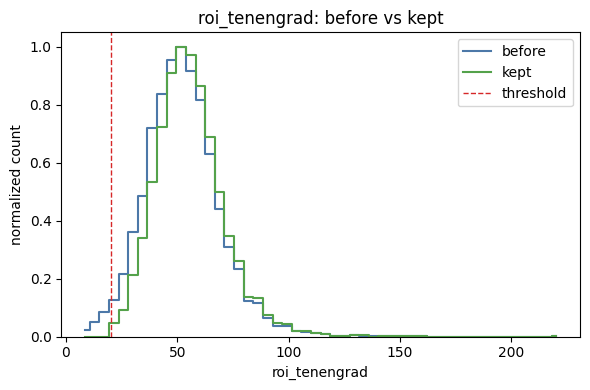

Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/roi_lap_var.png


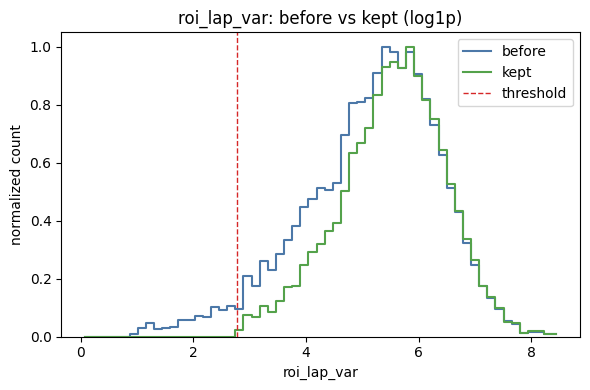

Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/jpg_blockiness.png


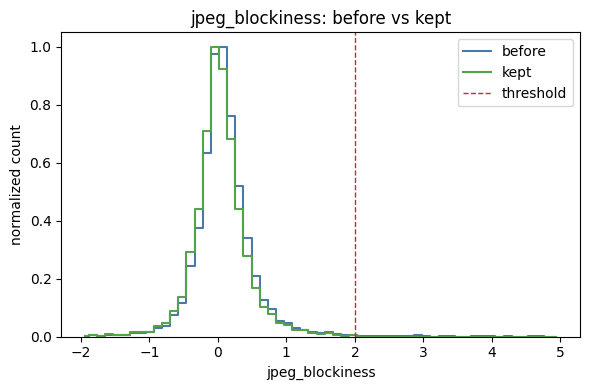

Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/niqe.png


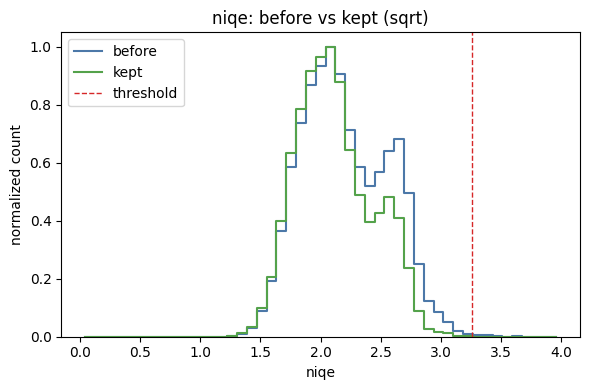

Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/brisque.png


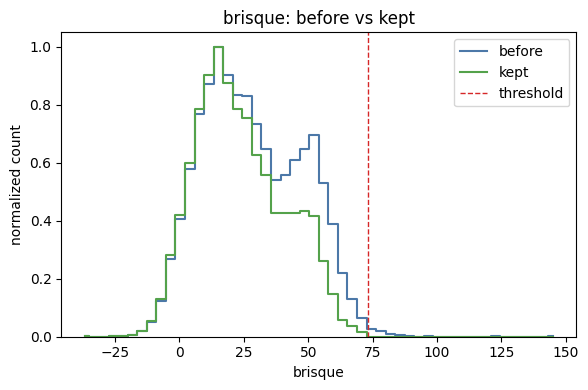

Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/bar_score.png


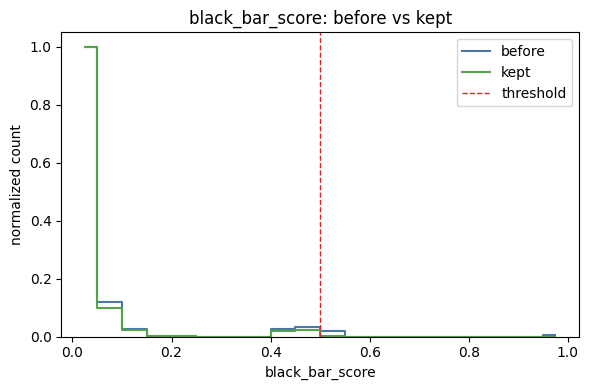

In [6]:
import math
import numpy as np
from dataset_quality import config as dq_config

METRIC_LIST = [
    m
    for m in ["roi_tenengrad", "roi_lap_var", "jpeg_blockiness", "niqe", "brisque", "black_bar_score"]
    if m in df.columns
]

THRESH_MAP = {
    "roi_lap_var": dq_config.THRESH.get("roi_lap_var_min"),
    "roi_tenengrad": dq_config.THRESH.get("roi_tenengrad_min"),
    "jpeg_blockiness": dq_config.THRESH.get("jpeg_blockiness_max"),
    "niqe": dq_config.THRESH.get("niqe_max"),
    "brisque": dq_config.THRESH.get("brisque_max"),
    "black_bar_score": dq_config.THRESH.get("black_bar_score_min"),
}

def _transform_series(metric, series):
    if metric == "roi_lap_var":
        return series.clip(lower=0, upper=5000).apply(lambda x: math.log1p(x)), "log1p"
    if metric == "niqe":
        return series.clip(lower=0, upper=16).apply(lambda x: math.sqrt(x)), "sqrt"
    return series, None

def _transform_value(metric, value):
    if value is None:
        return None
    if metric == "roi_lap_var":
        return math.log1p(min(max(value, 0), 5000))
    if metric == "niqe":
        return math.sqrt(min(max(value, 0), 16))
    return value

def _bins_for(metric):
    if metric == "black_bar_score":
        return np.linspace(0, 1, 21)
    if metric == "jpeg_blockiness":
        return np.linspace(-2, 5, 60)
    if metric == "roi_lap_var":
        return np.linspace(0, math.log1p(5000), 60)
    if metric == "niqe":
        return np.linspace(0, math.sqrt(16), 50)
    return 50

def plot_before_after(metric):
    before = df[metric].dropna()
    after = kept_df[metric].dropna()
    if before.empty or after.empty:
        return
    before_t, label = _transform_series(metric, before)
    after_t, _ = _transform_series(metric, after)
    bins = _bins_for(metric)

    counts_b, edges = np.histogram(before_t, bins=bins)
    counts_a, _ = np.histogram(after_t, bins=edges)

    if counts_b.max() > 0:
        counts_b = counts_b / counts_b.max()
    if counts_a.max() > 0:
        counts_a = counts_a / counts_a.max()

    centers = (edges[:-1] + edges[1:]) / 2

    fig = plt.figure(figsize=(6, 4))
    plt.plot(centers, counts_b, drawstyle="steps-mid", label="before", color="#4c78a8")
    plt.plot(centers, counts_a, drawstyle="steps-mid", label="kept", color="#54a24b")

    thr = THRESH_MAP.get(metric)
    thr_t = _transform_value(metric, thr)
    if thr_t is not None:
        plt.axvline(thr_t, color="#d62728", linestyle="--", linewidth=1, label="threshold")

    title = f"{metric}: before vs kept"
    if label:
        title += f" ({label})"
    plt.title(title)
    plt.xlabel(metric)
    plt.ylabel("normalized count")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    filename = METRIC_FILENAME_MAP.get(metric, f"{metric}.png")
    _save_figure(fig, filename)
    plt.show()

for metric in METRIC_LIST:
    plot_before_after(metric)


## Label Distributions (Before vs Kept)
Compare age/sex/ethnicity/emotion distributions before and after filtering.


Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/age.png


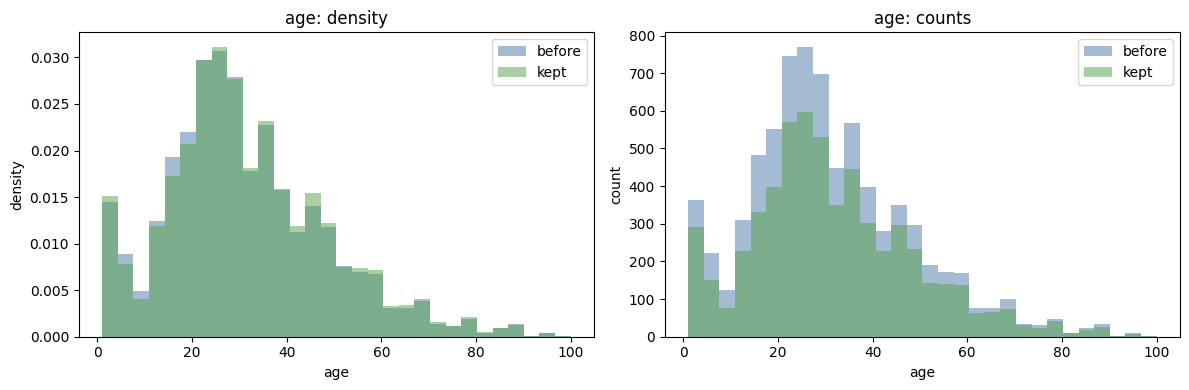

,before,kept,before_pct,kept_pct
age,,,,
1,149,125,0.019629,0.021481
2,88,72,0.011593,0.012373
3,25,16,0.003293,0.002750
4,101,78,0.013305,0.013404
5,87,66,0.011461,0.011342
...,...,...,...,...
94,5,4,0.000659,0.000687
95,2,2,0.000263,0.000344
96,2,2,0.000263,0.000344


Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/gender.png


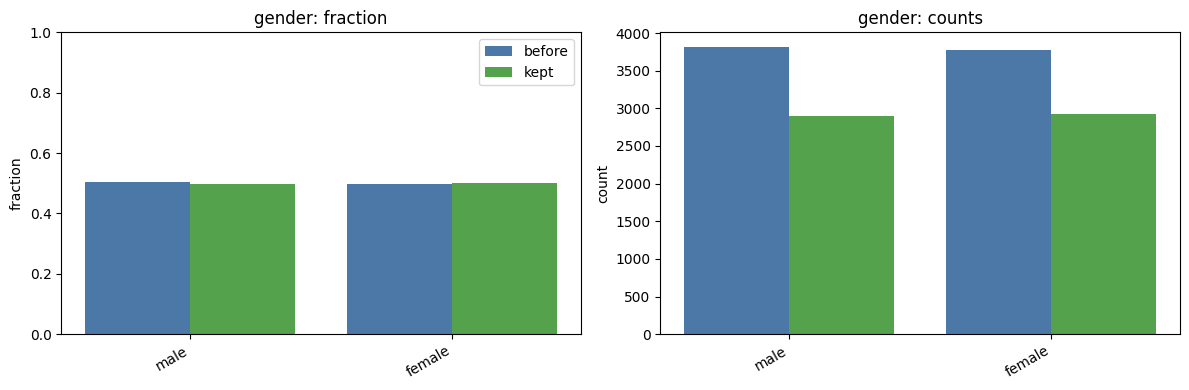

,before,kept,before_pct,kept_pct
gender,,,,
female,3773,2921,0.497036,0.501976
male,3818,2898,0.502964,0.498024


Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/ethnicity.png


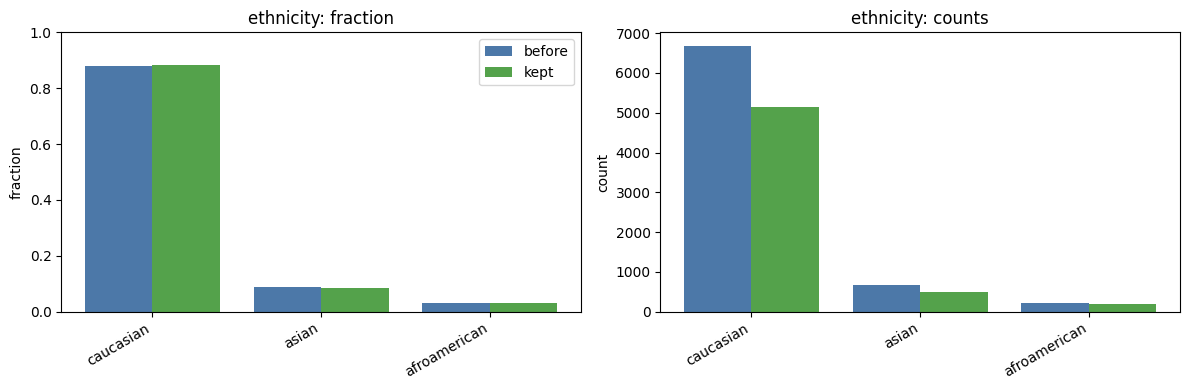

,before,kept,before_pct,kept_pct
ethnicity,,,,
caucasian,6686,5140,0.880780,0.883313
asian,674,488,0.088789,0.083863
afroamerican,231,191,0.030431,0.032824


Saved figure -> /home/fox/Desktop/Projects/Amrita RLHF/Diffusion_RL_Abi/figures/emotion.png


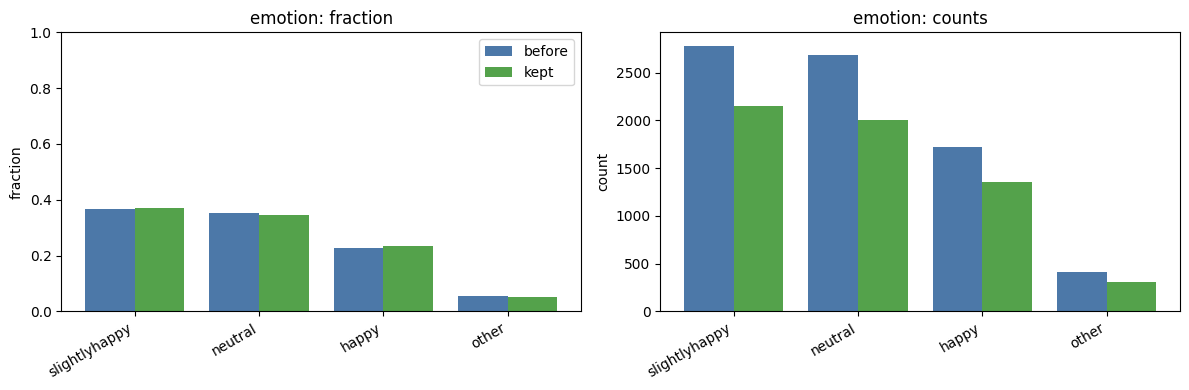

,before,kept,before_pct,kept_pct
emotion,,,,
slightlyhappy,2783,2151,0.366618,0.369651
neutral,2680,2008,0.353050,0.345076
happy,1717,1356,0.226189,0.233030
other,411,304,0.054143,0.052243


In [7]:
import numpy as np
from IPython.display import display

LABEL_COLS = [c for c in ["age", "gender", "ethnicity", "emotion"] if c in df.columns]

def _plot_categorical(col):
    before_counts = df[col].value_counts(dropna=False)
    kept_counts = kept_df[col].value_counts(dropna=False)
    cats = list(before_counts.index)

    before_vals = (before_counts / before_counts.sum()).reindex(cats).fillna(0.0)
    kept_vals = (kept_counts / kept_counts.sum()).reindex(cats).fillna(0.0)
    before_raw = before_counts.reindex(cats).fillna(0).astype(int)
    kept_raw = kept_counts.reindex(cats).fillna(0).astype(int)

    x = np.arange(len(cats))
    width = 0.4
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(x - width/2, before_vals.values, width=width, label="before", color="#4c78a8")
    axes[0].bar(x + width/2, kept_vals.values, width=width, label="kept", color="#54a24b")
    axes[0].set_title(f"{col}: fraction")
    axes[0].set_ylabel("fraction")
    axes[0].set_ylim(0, 1.0)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cats, rotation=30, ha="right")
    axes[0].legend()

    axes[1].bar(x - width/2, before_raw.values, width=width, label="before", color="#4c78a8")
    axes[1].bar(x + width/2, kept_raw.values, width=width, label="kept", color="#54a24b")
    axes[1].set_title(f"{col}: counts")
    axes[1].set_ylabel("count")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cats, rotation=30, ha="right")

    plt.tight_layout()
    _save_figure(fig, f"{col}.png")
    plt.show()

def _plot_age():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df["age"].dropna(), bins=30, alpha=0.5, label="before", color="#4c78a8", density=True)
    axes[0].hist(kept_df["age"].dropna(), bins=30, alpha=0.5, label="kept", color="#54a24b", density=True)
    axes[0].set_title("age: density")
    axes[0].set_xlabel("age")
    axes[0].set_ylabel("density")
    axes[0].legend()

    axes[1].hist(df["age"].dropna(), bins=30, alpha=0.5, label="before", color="#4c78a8")
    axes[1].hist(kept_df["age"].dropna(), bins=30, alpha=0.5, label="kept", color="#54a24b")
    axes[1].set_title("age: counts")
    axes[1].set_xlabel("age")
    axes[1].set_ylabel("count")
    axes[1].legend()

    plt.tight_layout()
    _save_figure(fig, "age.png")
    plt.show()

def _summary_table(col):
    before = df[col].value_counts(dropna=False)
    kept = kept_df[col].value_counts(dropna=False)
    summary = pd.DataFrame({"before": before, "kept": kept}).fillna(0).astype(int)
    summary["before_pct"] = summary["before"] / summary["before"].sum()
    summary["kept_pct"] = summary["kept"] / summary["kept"].sum()
    return summary

for col in LABEL_COLS:
    if col == "age":
        _plot_age()
    else:
        _plot_categorical(col)
    display(_summary_table(col))
